
SHAPE OF X :  (569, 30)

SHAPE OF Y :  (569,)

TRAINING ACCURACY :  1.0

TESTING ACCURACY :  0.9122807017543859


Depth: 1, Train: 0.9231, Test: 0.9211
Depth: 2, Train: 0.9582, Test: 0.8947
Depth: 3, Train: 0.9758, Test: 0.9386
Depth: 4, Train: 0.9868, Test: 0.9386
Depth: 5, Train: 0.9934, Test: 0.9211
Depth: 6, Train: 0.9978, Test: 0.9123
Depth: 8, Train: 1.0000, Test: 0.9123
Depth: 10, Train: 1.0000, Test: 0.9123
Depth: 15, Train: 1.0000, Test: 0.9123


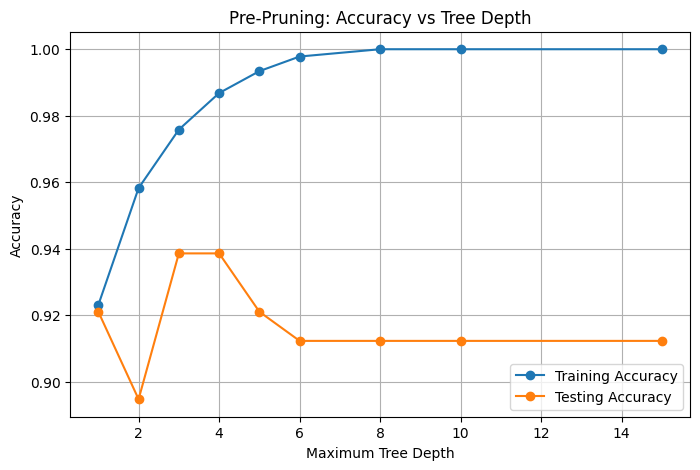

[0.         0.00218083 0.0028662  0.0029304  0.00395604 0.00425059
 0.00502355 0.00527473 0.00593407 0.00764113 0.01439037 0.02038595
 0.05433359 0.32661707]


Alpha:  0.0000, Train: 1.0000, Test: 0.9123
Alpha:  0.0022, Train: 0.9956, Test: 0.9211
Alpha:  0.0029, Train: 0.9912, Test: 0.9386
Alpha:  0.0029, Train: 0.9890, Test: 0.9386
Alpha:  0.0040, Train: 0.9868, Test: 0.9386
Alpha:  0.0043, Train: 0.9846, Test: 0.9386
Alpha:  0.0050, Train: 0.9824, Test: 0.9386
Alpha:  0.0053, Train: 0.9780, Test: 0.9298
Alpha:  0.0059, Train: 0.9736, Test: 0.9386
Alpha:  0.0076, Train: 0.9714, Test: 0.9386
Alpha:  0.0144, Train: 0.9582, Test: 0.8947
Alpha:  0.0204, Train: 0.9473, Test: 0.9035
Alpha:  0.0543, Train: 0.9231, Test: 0.9211
Alpha:  0.3266, Train: 0.6264, Test: 0.6316


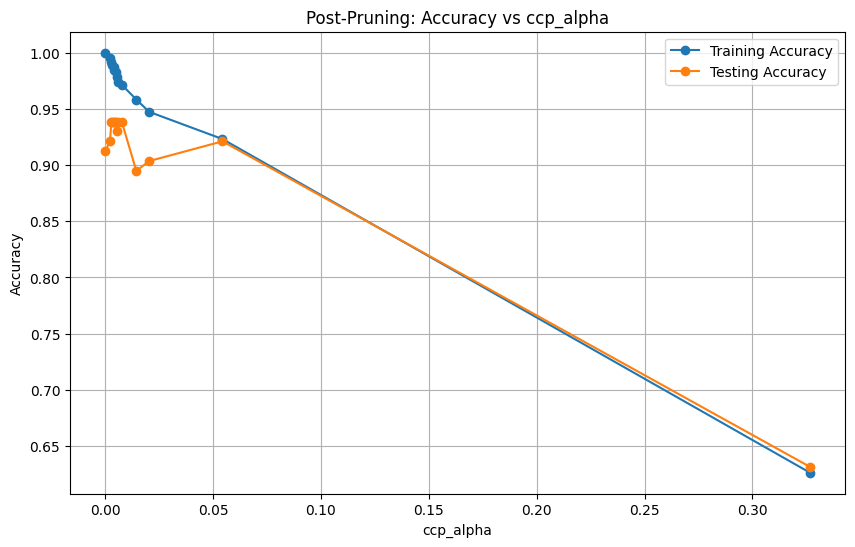


 BEST PRE PRUNING DEPTH IS 1
 BEST PRE PRUNING ALPHA IS 0.543


In [40]:
#PRUNING TO BE DONE ON DECISION TREE AND THE USED DATASET IS BREAST CANCER#




import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

data = load_breast_cancer()
X = data.data
y= data.target

print("\nSHAPE OF X : ",X.shape)
print("\nSHAPE OF Y : ",y.shape)

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state=42, stratify=y)

#UNPRUNED DECISION TREE

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

train_pred = dt.predict(X_train)
test_pred = dt.predict(X_test)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nTRAINING ACCURACY : ",train_accuracy)
print("\nTESTING ACCURACY : ",test_accuracy)

#PRE - PRUNED DECISION TREE

depths = [1, 2, 3, 4, 5, 6, 8, 10, 15]

train_scores = []
test_scores = []

for depth in depths:

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_scores.append(
        accuracy_score(y_train, train_pred)
    )

    test_scores.append(
        accuracy_score(y_test, test_pred)
    )

print("\n")
for depth, train_score, test_score in zip(
    depths,
    train_scores,
    test_scores
    ):
      print(
        f"Depth: {depth}, "
        f"Train: {train_score:.4f}, "
        f"Test: {test_score:.4f}"
    )


    #PLOTTING THE RESULTS

plt.figure(figsize=(8, 5))

plt.plot(depths, train_scores, marker='o', label='Training Accuracy')
plt.plot(depths, test_scores, marker='o', label='Testing Accuracy')

plt.xlabel("Maximum Tree Depth")
plt.ylabel("Accuracy")
plt.title("Pre-Pruning: Accuracy vs Tree Depth")
plt.legend()
plt.grid()

plt.show()


    #POST - PRUNED DECISION TREE

tree = DecisionTreeClassifier(
    random_state=42
)

tree.fit(X_train, y_train)

path = tree.cost_complexity_pruning_path(
    X_train,
    y_train
)

ccp_alphas = path.ccp_alphas

print(ccp_alphas)

train_scores = []
test_scores = []

for alpha in ccp_alphas :

  model = DecisionTreeClassifier(
      random_state=42,
      ccp_alpha = alpha
  )

  model.fit(X_train,y_train)


  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  train_scores.append(
      accuracy_score(y_train, train_pred)
  )

  test_scores.append(
      accuracy_score(y_test, test_pred)
  )

print("\n")
for alpha, train_score, test_score in zip(
    ccp_alphas,
    train_scores,
    test_scores
    ):
      print(
        f"Alpha: {alpha : .4f}, "
        f"Train: {train_score:.4f}, "
        f"Test: {test_score:.4f}"
    )

plt.figure(figsize=(10, 6))

plt.plot(
    ccp_alphas,
    train_scores,
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    ccp_alphas,
    test_scores,
    marker='o',
    label='Testing Accuracy'
)

plt.xlabel("ccp_alpha")
plt.ylabel("Accuracy")
plt.title("Post-Pruning: Accuracy vs ccp_alpha")
plt.legend()
plt.grid()

plt.show()


print("\n BEST PRE PRUNING DEPTH IS 1\n BEST PRE PRUNING ALPHA IS 0.543")

In [61]:
#LASSO AND RIDGE ARE REGULARIZATION TECHNIQUES AND THEY TELL THE MODELS NOT TO DEPEND ON THE COEFFICIENTS TOO MUCH


from sklearn.datasets import load_diabetes

data = load_diabetes()

X = data.data
y = data.target

print("\n SHAPE OF X : ",X.shape)
print("\n SHAPE OF Y : ",y.shape)


X_train, X_test, y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score,mean_squared_error

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

train_pred = linear_model.predict(X_train_scaled)
test_pred = linear_model.predict(X_test_scaled)

print("\nTRAIN R² : ",r2_score(y_train,train_pred))
print("\nTEST R² : ",r2_score(y_test,test_pred))


print("\nTrain MSE :",mean_squared_error(y_train, train_pred))

print("\nTest MSE :",mean_squared_error(y_test, test_pred))


#RIDGE REGRESSION

from sklearn.linear_model import Ridge

alphas = [0.1, 1.0, 5.0,10.0, 25.0 , 50.0 , 100.0]

for alpha in alphas:
    r_model = Ridge(alpha=alpha)

    r_model.fit(X_train_scaled, y_train)

    train_pred = r_model.predict(X_train_scaled)
    test_pred = r_model.predict(X_test_scaled)

    print("\n************* RIDGE REGRESSION WITH ALPHA =", alpha, "*************\n")

    print("\nRidge TRAIN R² :", round(r2_score(y_train, train_pred),4))
    print("\nRidge TEST R² :", round(r2_score(y_test, test_pred),4))
    print("\nRidge Train MSE :", round(mean_squared_error(y_train, train_pred),4))
    print("\nRidge Test MSE :", round(mean_squared_error(y_test, test_pred),4))


  #LASSO REGRESSION

from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0]

for alpha in alphas :

  l_model = Lasso(alpha = alpha)

  l_model.fit(X_train_scaled, y_train)

  train_pred = l_model.predict(X_train_scaled)
  test_pred = l_model.predict(X_test_scaled)

  print("\n************* LASSO REGRESSION WITH ALPHA =", alpha, "*************\n")
  print("\nRidge TRAIN R² :", round(r2_score(y_train, train_pred),4))
  print("\nRidge TEST R² :", round(r2_score(y_test, test_pred),4))
  print("\nRidge Train MSE :", round(mean_squared_error(y_train, train_pred),4))
  print("\nRidge Test MSE :", round(mean_squared_error(y_test, test_pred),4))



 SHAPE OF X :  (442, 10)

 SHAPE OF Y :  (442,)

TRAIN R² :  0.5279193863361498

TEST R² :  0.45260276297191926

Train MSE : 2868.549702835577

Test MSE : 2900.1936284934823

************* RIDGE REGRESSION WITH ALPHA = 0.1 *************


Ridge TRAIN R² : 0.5279

Ridge TEST R² : 0.4528

Ridge Train MSE : 2868.5777

Ridge Test MSE : 2899.0546

************* RIDGE REGRESSION WITH ALPHA = 1.0 *************


Ridge TRAIN R² : 0.5276

Ridge TEST R² : 0.4541

Ridge Train MSE : 2870.2961

Ridge Test MSE : 2892.0146

************* RIDGE REGRESSION WITH ALPHA = 5.0 *************


Ridge TRAIN R² : 0.526

Ridge TEST R² : 0.4561

Ridge Train MSE : 2880.3594

Ridge Test MSE : 2881.4286

************* RIDGE REGRESSION WITH ALPHA = 10.0 *************


Ridge TRAIN R² : 0.5248

Ridge TEST R² : 0.4572

Ridge Train MSE : 2887.5157

Ridge Test MSE : 2875.7787

************* RIDGE REGRESSION WITH ALPHA = 25.0 *************


Ridge TRAIN R² : 0.5229

Ridge TEST R² : 0.4593

Ridge Train MSE : 2899.2788

R